<center><font size=10> MNIST - Built-in Dataset
</center></font>
<center><font size=5>Modified National Institute of Standards and Technology</center></font

<center><p float="center">
  <img src="https://corochann.com/wp-content/uploads/2021/09/mnist_plot.png" width="720"/>
</p></center>

<center><font size=6>Handwritten digit Dataset</font></center>

## Data Description

- MNIST dataset contains `70,000` handwritten digits from ` 0 to 9`
- Each pixel has `28 × 28` pixels ranging from `0 to 255`
    - 0 stands for black
    - 255 stands for white

## Installing and importing the necessary libraries

In [ ]:
# Installing the libraries with the specified version
!pip install --no-deps --force-reinstall tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 --no-deps --force-reinstall -q --user --no-warn-script-location

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 42.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd  # Store and manipulate the data.
import numpy as np   # Performs numerical computations and array operations.
import matplotlib.pyplot as plt  # Plotting library for creating visualizations.
import seaborn as sns #For advanced visualizations.

from sklearn.model_selection import train_test_split  # Function for splitting datasets for training and testing.

import time  # Module for time-related operations.

import tensorflow as tf # Provides the deep learning framework for creating and training neural networks.
from tensorflow import keras  # High-level API used to build neural network models easily.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense   # for creating fully connected neural network layers.

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it might affect the overall performance
tf.config.experimental.enable_op_determinism()

## Loading the data

In [ ]:
# Loading the dataset from tensorflow datasets.
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Data Overview

In [ ]:
# Displaying the Shapes
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


**Sample images for different digits.**

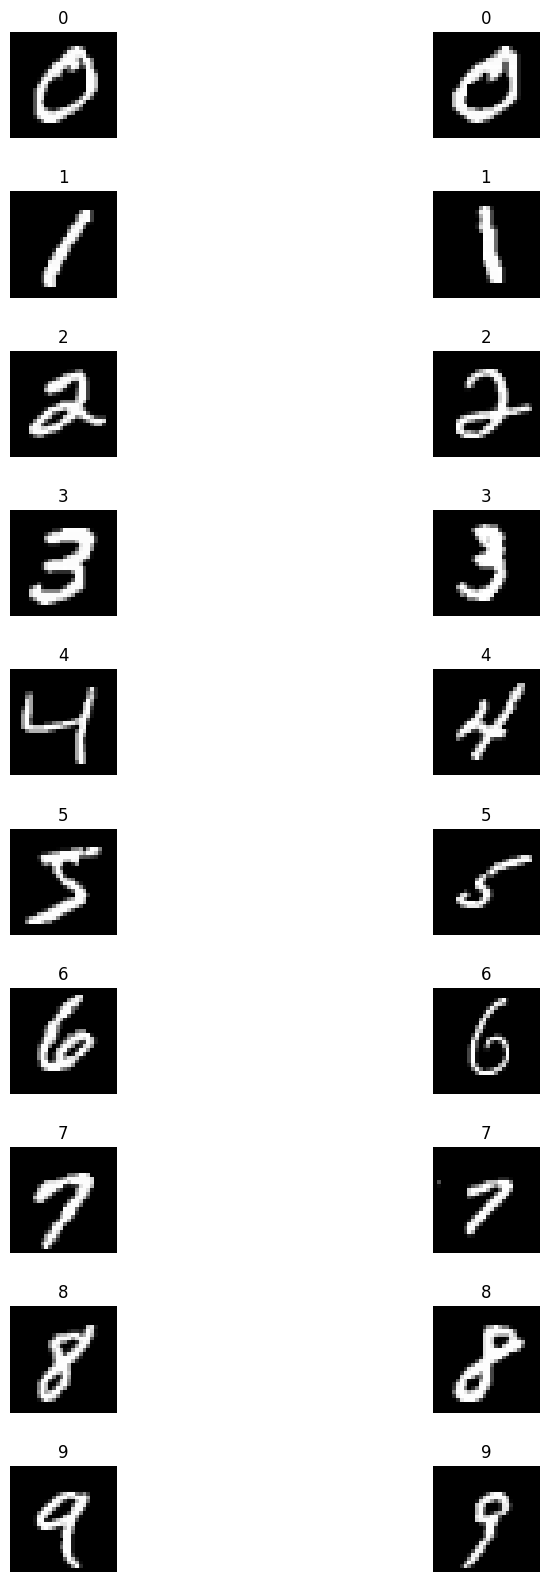

In [ ]:
f, axarr = plt.subplots(10,2,figsize=(10, 20)) #Grid of size 10*20, with 10 rows and 2 columns
for i in range(10): #For each digit
    images = x_train[y_train==i] #Filtering all the images based on the digit.
    axarr[i,0].imshow(images[0],cmap="gray") #Plotting the first one.
    axarr[i,1].imshow(images[1],cmap="gray") #Plotting the second one.
    axarr[i,0].axis('off')  # Hide axes
    axarr[i,1].axis('off')  # Hide axes
    axarr[i,0].set_title(str(i)) #Setting the title as the label of the digit.
    axarr[i,1].set_title(str(i)) #Setting the title as the label of the digit.

plt.subplots_adjust(hspace=0.5)  # Adjust spacing between subplots
plt.show() #Displaying the plot.

The plot display and confirms that all digit classes (0–9) are present and shows natural variations in handwriting among different samples, making the dataset suitable for training a neural network that can accurately classify unseen handwritten digits.


**Distribution of images in `y_train` across diffrent classes**

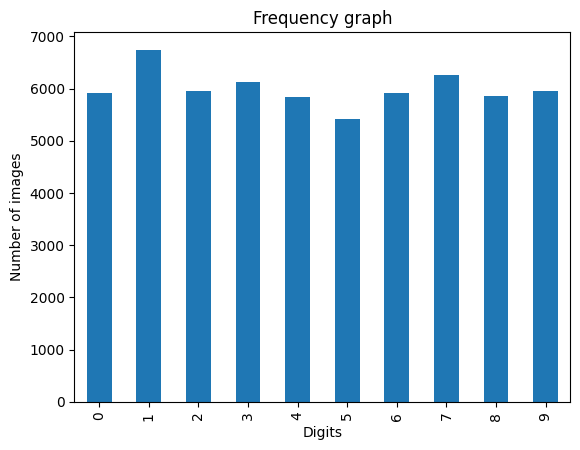

In [ ]:
# frequency plot of the dependent variable in the training dataset
(pd.Series(y_train).value_counts())[[0,1,2,3,4,5,6,7,8,9]].plot.bar()
plt.title("Frequency graph") #Setting the title
plt.xlabel("Digits") #Defining the label for the x-axis
plt.ylabel("Number of images") #Defining the label for the y-axis.
plt.show() #Displaying the plot.

**Distribution of images in `y_test` across diffrent classes**

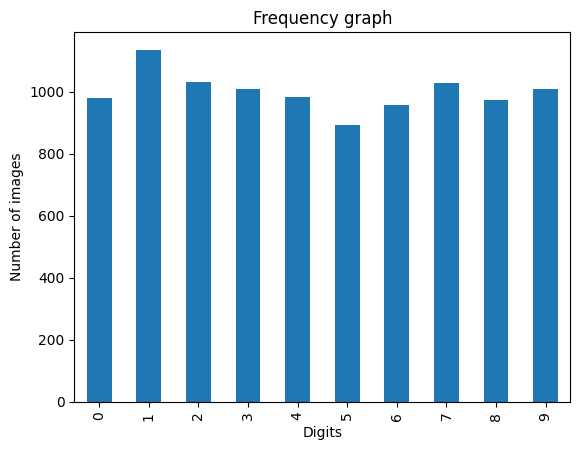

In [ ]:
(pd.Series(y_test).value_counts())[[0,1,2,3,4,5,6,7,8,9]].plot.bar()
plt.title("Frequency graph") #Setting the title
plt.xlabel("Digits") #Defining the label for the x-axis
plt.ylabel("Number of images") #Defining the label for the y-axis.
plt.show() #Displaying the plot.

## Data Preprocessing

- Exploring its structure
- `Normalizing` pixel values to the range `0–1`
- `Reshaping` each `28 × 28` image into a `784` and
- `One-hot encoding`- the target variable, the digit labels to prepare the data for neural network training.


### Data Preparation for Modeling

In [ ]:
#  Splitting the training dataset in the ratio 5:1 for train and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=1-(5/6), random_state=42,stratify=y_train)

- `stratify` - splitting the data while preserving the same class distribution in both train and test data.

In [ ]:
# Displaying the shape of the dataset.
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

(50000, 28, 28)
(50000,)
(10000, 28, 28)
(10000,)


### Data Scaling

- Convert pixel values from 0–255 to 0–1 by dividing by 255 to make it in same range ∈ $[0,1]$
- This helps the neural network train faster and more effectively.

In [ ]:
# Displaying maxium and minimum value(before normalizing).
print(x_train.max(),x_test.max(),x_val.max())
print(x_train.min(),x_test.min(),x_val.min())

255 255 255
0 0 0


In [ ]:
# Normalizing the dataset
x_train, x_val, x_test = x_train.astype("float32")/(255), x_val.astype("float32")/(255), x_test.astype("float32")/(255)

In [ ]:
# Displaying maxium and minimum value(after normalizing).
print(x_train.max(),x_test.max(),x_val.max())
print(x_train.min(),x_test.min(),x_val.min())

1.0 1.0 1.0
0.0 0.0 0.0


- Previously, the range was $[0,255]$
- Now, the range after normalizing is $[0,1]$

### Reshaping the input

- The neural network accepts 1D input.

Reshape the image data from $(n,h,w)$ to $(n,h*w)$, where
- $n$ = number of images in the dataset
- $h$ = height of the image
- $w$ = width of the image

For example, image data of dimension $(50000,28,28)$ is transformed to $(50000,28*28)$, i.e., $(50000,784)$.

In [ ]:
# Reshaping
x_train = x_train.reshape(x_train.shape[0],-1)
x_val = x_val.reshape(x_val.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)

  -  In NumPy, Automatically calculate the required number of columns.

In [ ]:
print(x_train.shape[0], "train samples")
print(x_val.shape[0], "validation samples")
print(x_test.shape[0], "test samples")

50000 train samples
10000 validation samples
10000 test samples


### Encoding the target variable

- Convert class labels (0–9) into one-hot encoded vectors.

  Example:

    3 => [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

In [ ]:
# specifying the number of classes
num_classes = 10

In [ ]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)

In [ ]:
y_train

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [ ]:
y_train.shape

(50000, 10)

 - Each label is converted into a 10-dimensional one-hot vector with 1 for the correct class and 0 for all others.


## Utility functions

In [ ]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

- The plot illustrates the model's performance on both the training and validation datasets over multiple epochs.

- An increasing accuracy (or decreasing loss) for both datasets indicates effective learning.

- If the training and validation **curves** remain `close`, the model generalizes `well`, whereas a `large gap` between them indicates `overfitting`.


Dataframe to store the results from all the Models.

In [ ]:
# Defining the columns in the dataframe.
columns = ["# hidden layers","# neurons - hidden layer","activation function - hidden layer","# epochs","batch size","train loss","validation loss","train accuracy","validation accuracy","time (secs)"]

#Creating a pandas dataframe.
results = pd.DataFrame(columns=columns)

## Model Building

### Model 0

- Baseline model (no hidden layer).
- No hidden layer, Softmax output, SGD, Batch size = Full dataset, 10


In [ ]:
# clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
# initializing the neural network
model = Sequential()

# Adding a dense layer with softmax activation function, with the input dimension determined by the shape of the training data.
model.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[1]))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

* **Dense Layer:** A fully connected layer where each input neuron is connected to every output neuron.
* **Output Shape `(None, 10)`:** `None` represents a variable batch size, and `10` represents the number of output neurons (one for each digit class).
* **Parameters (7850):** Consists of **7,840 weights** (784 × 10) and **10 bias terms**, giving a total of **7,850 trainable parameters**.


In [ ]:
#Compiling the model.
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
batch_size = x_train.shape[0]
epochs = 10

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
start = time.time()

# Fitting the model.
history = model.fit(
    x_train, y_train,
    validation_data=(x_val,y_val),
    batch_size=batch_size,
    epochs=epochs
)

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
end = time.time()

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0933 - loss: 2.3785 - val_accuracy: 0.1019 - val_loss: 2.3576
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step - accuracy: 0.0996 - loss: 2.3633 - val_accuracy: 0.1081 - val_loss: 2.3429
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.1053 - loss: 2.3485 - val_accuracy: 0.1159 - val_loss: 2.3286
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.1115 - loss: 2.3342 - val_accuracy: 0.1224 - val_loss: 2.3148
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.1180 - loss: 2.3203 - val_accuracy: 0.1286 - val_loss: 2.3014
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.1244 - loss: 2.3068 - val_accuracy: 0.1342 - val_loss: 2.2882
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.1313 - loss: 2.2936 - val_accuracy: 0.1408 - val_loss: 2.2755
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.1380 - loss: 2.2807 - val_accuracy: 0.1480 - val_loss: 2.

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  5.609691858291626


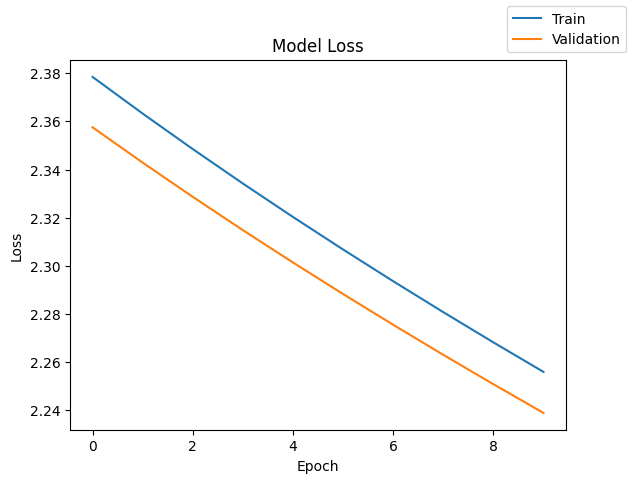

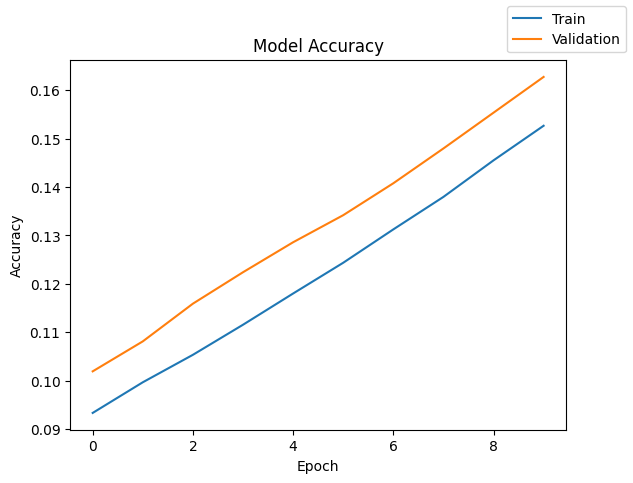

In [ ]:
plot(history,'loss')
plot(history,'accuracy')

In [ ]:
results.loc[0] = [0,'-','-',10,50000,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.1527,0.1628,5.61


### Model 1

- Same architecture as Model 0, 50 epochs

In [ ]:
# clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_1 = Sequential()
model_1.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[1]))
model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = x_train.shape[0]
epochs = 50
model_1.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_1.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0724 - loss: 2.4184 - val_accuracy: 0.0749 - val_loss: 2.4064
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.0750 - loss: 2.4036 - val_accuracy: 0.0784 - val_loss: 2.3921
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.0777 - loss: 2.3893 - val_accuracy: 0.0819 - val_loss: 2.3783
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.0804 - loss: 2.3754 - val_accuracy: 0.0847 - val_loss: 2.3649
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.0844 - loss: 2.3619 - val_accuracy: 0.0879 - val_loss: 2.3518
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.0879 - loss: 2.3487 - val_accuracy: 0.0912 - val_loss: 2.3390
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.0916 - loss: 2.3359 - val_accuracy: 0.0951 - val_loss: 2.3265
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.0961 - loss: 2.3234 - val_accuracy: 0.1005 - val_loss: 2.

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  18.348918914794922


In [ ]:
results.loc[1]= [0,'-','-',50,50000,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.1527,0.1628,5.61
1,0,-,-,50,50000,1.927448,1.924149,0.4306,0.4332,18.35


- The accuracy has improved significantly compared to the previous model (~180%)
- The time taken to train has also increased.

### Model 2

- Same architecture, Batch size = 32, 10 epochs

In [ ]:
#clears the current Keras session.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_2 = Sequential()
model_2.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[1]))
model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 10
model_2.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_2.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8081 - loss: 0.8309 - val_accuracy: 0.8657 - val_loss: 0.5347
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8778 - loss: 0.4763 - val_accuracy: 0.8815 - val_loss: 0.4438
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8883 - loss: 0.4176 - val_accuracy: 0.8886 - val_loss: 0.4066
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8943 - loss: 0.3885 - val_accuracy: 0.8949 - val_loss: 0.3852
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8988 - loss: 0.3702 - val_accuracy: 0.8986 - val_loss: 0.3709
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9019 - loss: 0.3572 - val_accuracy: 0.9011 - val_loss: 0.3604
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9035 - loss: 0.3474 - val_accuracy: 0.9029 - val_loss: 0.3524
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9054 - loss: 0.3396 - 

The model achieved a significant improvement in accuracy, reaching about 80% after just one epoch. More frequent parameter updates enabled faster learning and better performance in nearly the same training time.


In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  39.16163778305054


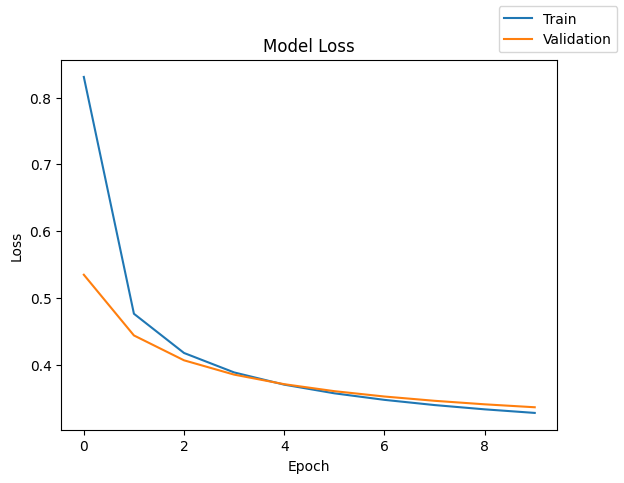

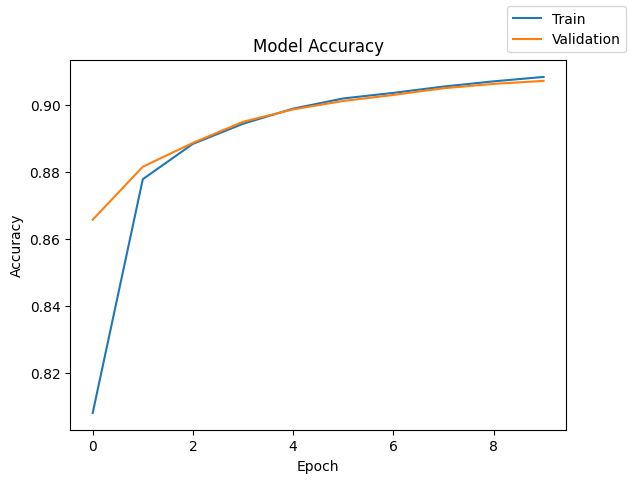

In [ ]:
plot(history,'loss')
plot(history,'accuracy')

In [ ]:
results.loc[2] = [0,'-','-',10,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,train loss,validation loss,train accuracy,validation accuracy,time (secs)
0,0,-,-,10,50000,2.255868,2.238811,0.15270,0.1628,5.61
1,0,-,-,50,50000,1.927448,1.924149,0.43060,0.4332,18.35
2,0,-,-,10,32,0.327848,0.336322,0.90828,0.9071,39.16


### Model 3

- Same architecture, Batch size = 32, 50 epochs

In [ ]:
#clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_3 = Sequential()
model_3.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[1]))
model_3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 50
model_3.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_3.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8067 - loss: 0.8327 - val_accuracy: 0.8658 - val_loss: 0.5356
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8776 - loss: 0.4767 - val_accuracy: 0.8823 - val_loss: 0.4446
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8884 - loss: 0.4180 - val_accuracy: 0.8904 - val_loss: 0.4070
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8944 - loss: 0.3887 - val_accuracy: 0.8953 - val_loss: 0.3853
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8983 - loss: 0.3703 - val_accuracy: 0.8997 - val_loss: 0.3708
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9016 - loss: 0.3572 - val_accuracy: 0.9017 - val_loss: 0.3603
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9042 - loss: 0.3473 - val_accuracy: 0.9034 - val_loss: 0.3522
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9057 - loss: 0.3395 - 

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
results.loc[3] = [0,'-','-',50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

### Model 4

- Same architecture, Batch size = 64, 50 epochs

In [ ]:
#clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_4 = Sequential()
model_4.add(Dense(num_classes, activation = 'softmax', input_dim = x_train.shape[1]))
model_3.summary()

In [ ]:
batch_size = 64
epochs = 50
model_4.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_4.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
results.loc[4] = [0,'-','-',50,64,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

- Increasing the **batch size** to `64` reduced training time by about `50%` with only a slight `decrease in accuracy`.
- The next step is to **add a hidden layer**and compare the performance of vanilla Gradient Descent and Stochastic Gradient Descent using the updated neural network architecture.


### Model 5

- One hidden layer (64 neurons, Sigmoid) + Softmax output

In [ ]:
#clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_5 = Sequential()
model_5.add(Dense(64,activation='sigmoid',input_dim = x_train.shape[1]))
model_5.add(Dense(num_classes, activation = 'softmax'))
model_5.summary()

- As the network has one hidden and one output layer, both being dense layers, the same is reflected in the model summary

- The computation of the total number of parameters in the model

- Each of the 784 input neurons is connected to the 64 neurons in the hidden layer

    => `784*64 = 50176` weight `+ 64 bias` parameters, `= 50240` parameters for the connections between the input and hidden layers.

- Each of the 64 neurons in the hidden layer is connected to the 10 neurons in the output layer.

    => `64*10 = 640` weight `+ 10 bias` parameters, `= 650` parameters for the connections between the hidden and output layers.

Thus, the total number of parameters is 50240 + 650 = 50890

In [ ]:
batch_size = x_train.shape[0]
epochs = 50
model_5.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [ ]:
start = time.time()
history = model_5.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')
plot(history,'accuracy')

- The validation loss is consistently lower than the training loss, resulting in higher validation accuracy than training accuracy throughout the training process.


In [ ]:
results.loc[5] = [1,64,'sigmoid',50,50000,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

### Model 6

- Same as Model 5, 50 epochs

In [ ]:
#clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_6 = Sequential()
model_6.add(Dense(64,activation='sigmoid',input_dim = x_train.shape[1]))
model_6.add(Dense(num_classes, activation = 'softmax'))
model_6.summary()

In [ ]:
batch_size = 32
epochs = 50
model_6.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_6.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
results.loc[6] = [1,64,'sigmoid',50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

### Model 7

- 128 Sigmoid neurons in hidden layer

In [ ]:
#clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_7 = Sequential()
model_7.add(Dense(128,activation='sigmoid',input_dim = x_train.shape[1]))
model_7.add(Dense(num_classes, activation = 'softmax'))
model_7.summary()

In [ ]:
batch_size = 32
epochs = 50
model_7.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_7.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
results.loc[7] = [1,128,'sigmoid',50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

- Adding more neurons to the hidden layer hasn't help much

### Model 8

- 128 Tanh neurons in the hidden layer

In [ ]:
#clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_8 = Sequential()
model_8.add(Dense(128,activation='tanh',input_dim = x_train.shape[1]))
model_8.add(Dense(num_classes, activation = 'softmax'))
model_8.summary()

In [ ]:
batch_size = 32
epochs = 50
model_8.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_8.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')
plot(history,'accuracy')

In [ ]:
results.loc[8] = [1,128,'tanh',50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

- With **tanh as the activation function**, got 4% improvement with the same time spent.

- Hence, matters the choice of activation function.

### Model 9

- 128 ReLU neurons

In [ ]:
#clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_9 = Sequential()
model_9.add(Dense(128,activation='relu',input_dim = x_train.shape[1]))
model_9.add(Dense(num_classes, activation = 'softmax'))
model_9.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 32
epochs = 50
model_9.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_9.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8296 - loss: 0.6917 - val_accuracy: 0.8878 - val_loss: 0.4004
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9030 - loss: 0.3486 - val_accuracy: 0.9101 - val_loss: 0.3247
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9156 - loss: 0.2978 - val_accuracy: 0.9194 - val_loss: 0.2898
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9246 - loss: 0.2681 - val_accuracy: 0.9259 - val_loss: 0.2664
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9314 - loss: 0.2461 - val_accuracy: 0.9315 - val_loss: 0.2485
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9363 - loss: 0.2282 - val_accuracy: 0.9352 - val_loss: 0.2336
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9404 - loss: 0.2130 - val_accuracy: 0.9390 - val_loss: 0.2209
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9439 - loss: 0.1998 - 

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')
plot(history,'accuracy')

In [ ]:
results.loc[9] = [1,128,'relu',50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

- With **relu as the activation function**, the performance improved slightly (~0.6%)

### Model 10

- Two hidden layers: 128 ReLU → 64 Tanh

In [ ]:
#clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_10 = Sequential()
model_10.add(Dense(128,activation='relu',input_dim = x_train.shape[1]))
model_10.add(Dense(64,activation='tanh'))
model_10.add(Dense(num_classes, activation = 'softmax'))
model_10.summary()

In [ ]:
batch_size = 32
epochs = 50
model_10.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_10.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')
plot(history,'accuracy')

In [ ]:
results.loc[10] = [2,[128,64],['relu','tanh'],50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

- Adding a **second hidden layer** slightly improved the model's accuracy.

- The performance gain depends on the combined effect of hyperparameters, and the next experiment evaluates whether changing the order of the hidden-layer activation functions further improves performance.

### Model 11

- Two hidden layers: 128 Tanh → 64 ReLU

    => Changing the order of hidden layer

In [ ]:
#clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_11 = Sequential()
model_11.add(Dense(128,activation='tanh',input_dim = x_train.shape[1]))
model_11.add(Dense(64,activation='relu'))
model_11.add(Dense(num_classes, activation = 'softmax'))
model_11.summary()

In [ ]:
batch_size = 32
epochs = 50
model_11.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_11.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
results.loc[10] = [2,[128,64],['relu','tanh'],50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

### Model 12

- Three hidden layers: 128 ReLU → 64 ReLU → 32 ReLU

In [ ]:
#clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_12 = Sequential()
model_12.add(Dense(128,activation='relu',input_dim = x_train.shape[1]))
model_12.add(Dense(64,activation='relu'))
model_12.add(Dense(32,activation='relu'))
model_12.add(Dense(num_classes, activation = 'softmax'))
model_12.summary()

In [ ]:
batch_size = 32
epochs = 50
model_12.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_12.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')
plot(history,'accuracy')

In [ ]:
results.loc[10] = [2,[128,64],['relu','tanh'],50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

### Model 13

- Same as Model 12, 100 epoch

In [ ]:
#clears the current Keras session
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_13 = Sequential()
model_13.add(Dense(128,activation='relu',input_dim = x_train.shape[1]))
model_13.add(Dense(64,activation='relu'))
model_13.add(Dense(32,activation='relu'))
model_13.add(Dense(num_classes, activation = 'softmax'))
model_13.summary()

In [ ]:
batch_size = 32
epochs = 100
model_13.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

start = time.time()
history = model_13.fit(x_train, y_train, validation_data=(x_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')
plot(history,'accuracy')

In [ ]:
results.loc[10] = [2,[128,64],['relu','tanh'],50,32,history.history["loss"][-1],history.history["val_loss"][-1],history.history["accuracy"][-1],history.history["val_accuracy"][-1],round(end-start,2)]

results

- The training accuracy has reached it's peak (100% accurate)

- The validation accuracy doesn't have changed much in the last few models.

- The validation accuracy in the range [0.9700 - 0.9760] in the last few models.

The time taken for 100 epochs, is almost double.

## Best Model

###**Model 9**

Contians:
- Input Layer (784 neurons)
- Hidden Layer: 128 neurons (ReLU activation)
- Output Layer: 10 neurons (Softmax activation)

> **Model 9** achieves high validation accuracy using ReLU activation with a simple architecture, faster training, and a lower risk of overfitting, making it an balance between accuracy, efficiency, and model complexity.


## Conclusions

- Models 0–4: Baseline models with no hidden layers. These investigate the effects of epochs and batch size.


- Models 5–9: Introduce one hidden layer and compare the effects of number of neurons and activation functions (Sigmoid, Tanh, ReLU).


- Models 10–13: Build deeper neural networks with multiple hidden layers and examine how increasing depth and training duration affects performance and overfitting.

## Prediction for unseen Data

In [ ]:
# Select one unseen sample from the test set
index = 25

sample = x_test[index].reshape(1, 784)

# Predict the class probabilities
prediction = model_9.predict(sample)

# Predicted digit
predicted_class = prediction.argmax(axis=1)[0]

# Actual digit
actual_class = y_test[index]

print("Actual Digit   :", actual_class)
print("Predicted Digit:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Actual Digit   : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Predicted Digit: 0


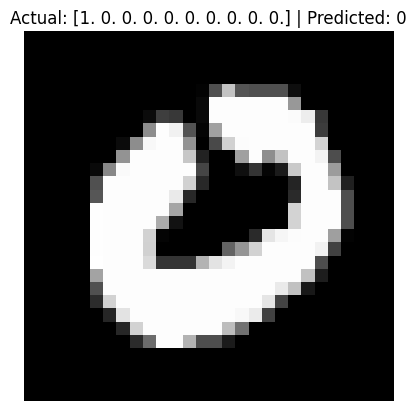

In [ ]:
plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title(f"Actual: {actual_class} | Predicted: {predicted_class}")
plt.axis('off')
plt.show()

Model 9 correctly classified the unseen handwritten digit from the test dataset, demonstrating its ability to generalize well to new data. This indicates that the trained model can accurately recognize handwritten digits it has not encountered during training.
